In [56]:
import numpy as n
import matplotlib.pyplot as plot
import pandas as p
data=p.read_csv("ESG_Sustainability_csv.csv")


In [6]:
revenue = data["Revenue_Mission"].values
carbon = data["Carbon_Emission_Tons"].values
renewable = data["Renewable_Energy_Percent"].values
diversity = data["Employee_Diversity_Score"].values
safety = data["Safety_Incidents"].values
governance = data["Governance_Score"].values
satisfaction = data["Employee_Satisfaction"].values
training = data["Training_Hours"].values

KPI

In [8]:
carbon_efficiency=(revenue/carbon)
employee_wellbeing=((satisfaction/satisfaction.max())*60+(training/training.max())*40)*100
esg_score=((renewable/renewable.max())*30+(diversity/diversity.max())*20+(governance/governance.max())*25+(employee_wellbeing/employee_wellbeing.max())*15+(1-safety/safety.max())*10)*100
risk_score=((carbon/carbon.max())*40+(safety/safety.max())*30+(1-governance/governance.max())*30)*100
carbon_intelligence=((revenue/revenue.max())*50+(1-carbon/carbon.max())*50)*100
human_capital=((diversity/diversity.max())*35+(satisfaction/satisfaction.max())*35+(training/training.max())*30)*100
sustainability_momentum=((renewable/renewable.max())*60+(governance/governance.max())*40)*100
esg_innovation=(carbon_intelligence*0.30+human_capital*0.25+sustainability_momentum*0.45)
resilience_score=((1-safety/safety.max())*40+(governance/governance.max())*30+(satisfaction/satisfaction.max())*30)*100
future_risk=((carbon/carbon.max())*35+(safety/safety.max())*35+(1-renewable/renewable.max())*15+(1-governance/governance.max())*15)*100

In [9]:
#Anomaly Detect
threshold=n.mean(risk_score)+2*n.std(risk_score)
high_risk=(risk_score>threshold)

In [10]:
data["Carbon_Effciency"]=n.round(carbon_efficiency,2)
data["Employee_Wellbeing"]=n.round(employee_wellbeing,2)
data["ESG_Score"]=n.round(esg_score,2)
data["Risk_Score"]=n.round(risk_score,2)
data["High_Risk"]=high_risk
data["Carbon_Intelligence"] = n.round(carbon_intelligence,2)
data["Human_Capital"] = n.round(human_capital,2)
data["Sustainability_Momentum"] = n.round(sustainability_momentum,2)
data["ESG_Innovation"] = n.round(esg_innovation,2)
data["Resilience_Score"] = n.round( resilience_score,2)
data["Future_Risk"] = n.round(future_risk,2)

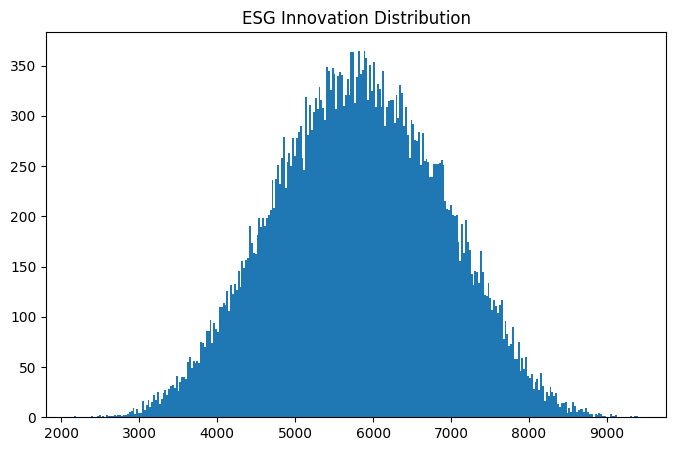

In [9]:
plot.figure(figsize=(8,5))
plot.hist(esg_innovation,bins=300)
plot.title("ESG Innovation Distribution")
plot.show()

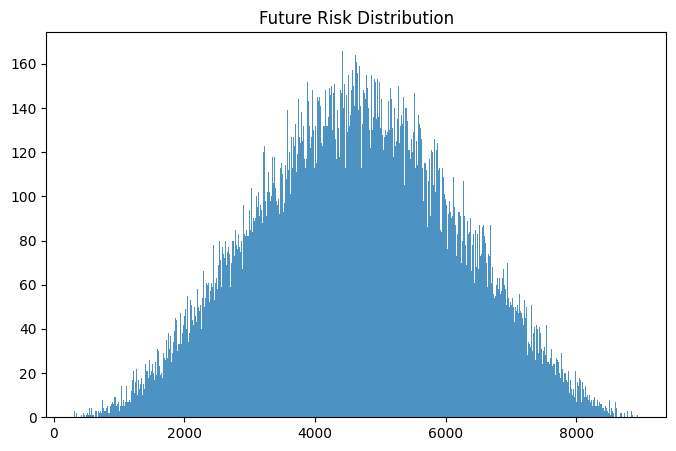

In [12]:
plot.figure(figsize=(8,5))
plot.hist(future_risk,bins=600,alpha=0.8)
plot.title("Future Risk Distribution")
plot.show()

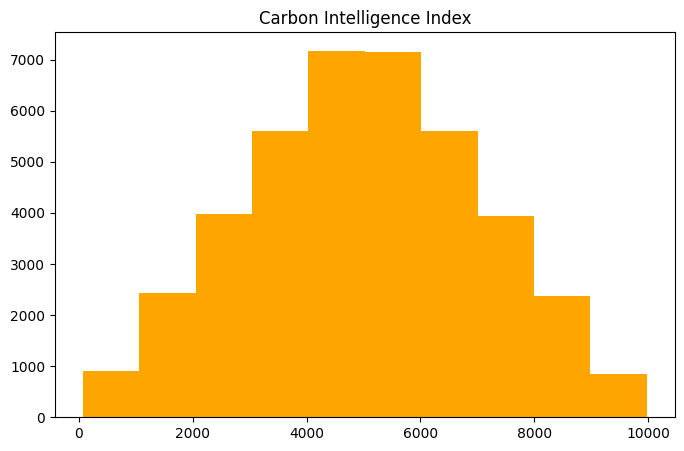

In [18]:
plot.figure(figsize=(8,5))
plot.hist(carbon_intelligence,bins=10,color="orange")
plot.title("Carbon Intelligence Index")
plot.show()

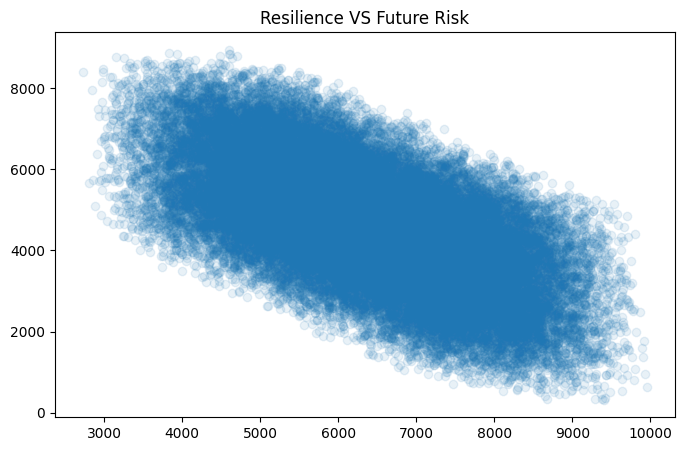

In [21]:
plot.figure(figsize=(8,5))
plot.scatter(resilience_score,future_risk,alpha=0.1)
plot.title("Resilience VS Future Risk")
plot.show()

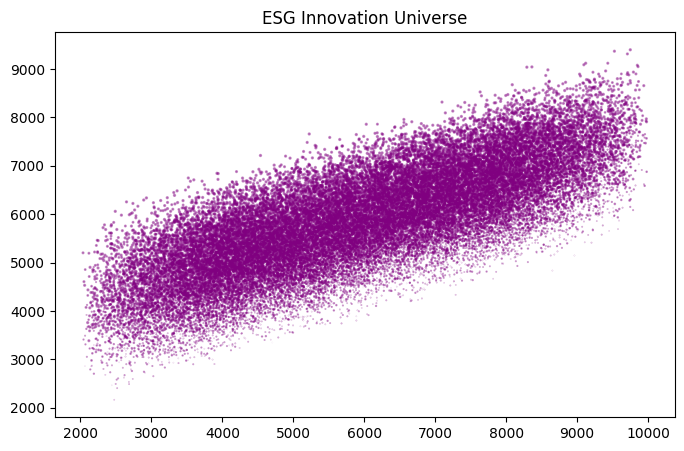

In [29]:
plot.figure(figsize=(8,5))
plot.scatter(sustainability_momentum,esg_innovation,s=revenue/5000,alpha=0.4,color="purple")
plot.title("ESG Innovation Universe")
plot.show()

Industry
Telecom          5834.011343
Technology       5824.142545
Energy           5822.749952
Retail           5817.294519
Finance          5808.301412
Manufacturing    5797.666005
Healthcare       5795.876424
Name: ESG_Innovation, dtype: float64


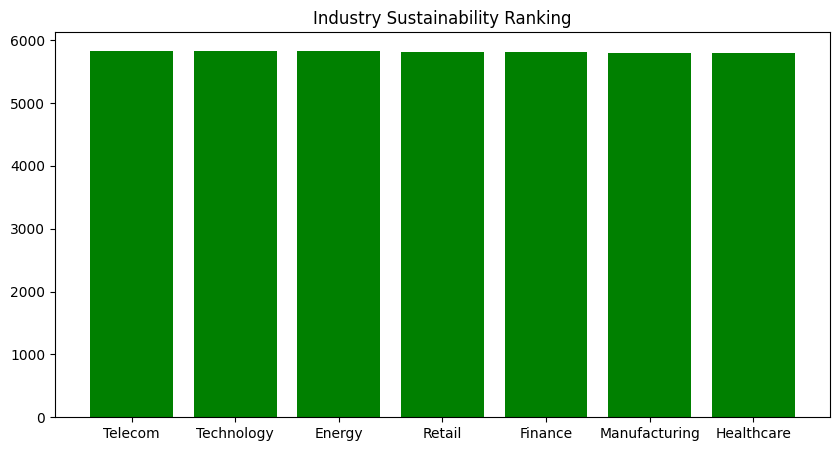

In [35]:
plot.figure(figsize=(10,5))
industry_ranking=(data.groupby("Industry")["ESG_Innovation"].mean().sort_values(ascending=False))
print(industry_ranking)
plot.bar(industry_ranking.index,industry_ranking.values,color="green")
plot.title("Industry Sustainability Ranking")
plot.show()

In [55]:
data.to_excel(
    "ESG_Analytics_Report.xlsx",
    index=False
)

print("Report Saved Successfully")

Report Saved Successfully
